# Motif Decomposition Visualizer

A visual walkthrough showing that a discovered algorithm (irr_pair11) is
**a composition of common, irreducible subgraphs from existing algorithms**.

Pipeline: `Qiskit Circuit → ZX Diagram → NetworkX Graph → Motif Decomposition → Cross-Algorithm Search`

In [1]:
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pyzx as zx

from zx_motifs.algorithms.registry import ALGORITHM_FAMILY_MAP, REGISTRY
from zx_motifs.pipeline.ansatz import irr_pair11_entangler, irr_pair11_original_6q
from zx_motifs.pipeline.converter import (
    SimplificationLevel, convert_at_all_levels, qiskit_to_zx,
)
from zx_motifs.pipeline.featurizer import pyzx_to_networkx
from zx_motifs.pipeline.matcher import MotifPattern, find_motif_in_graph
from zx_motifs.pipeline.decomposer import decompose_graph
from zx_motifs.motifs.registry import MOTIF_REGISTRY

%matplotlib inline
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

---
## 1. The Discovered Circuit

irr_pair11 was discovered by composing two irreducible ZX motifs:
**phase_gadget_3t** (a T-gate spider with 3 Hadamard legs) and
**cluster_chain** (a Hadamard-edge path from cluster states).

Let's start from the Qiskit circuit.

In [2]:
qc = irr_pair11_original_6q()
print("irr_pair11 — original 6-qubit circuit")
print(f"  {qc.num_qubits} qubits, {qc.size()} gates, depth {qc.depth()}")
print()
print(qc.draw(output="text"))

irr_pair11 — original 6-qubit circuit
  6 qubits, 12 gates, depth 8

     ┌───┐┌───┐┌───┐                              
q_0: ┤ X ├┤ X ├┤ X ├────────────■─────────────────
     └─┬─┘└─┬─┘└─┬─┘          ┌─┴─┐               
q_1: ──■────┼────┼────■────■──┤ X ├───────■───────
            │    │  ┌─┴─┐  │  └───┘┌───┐┌─┴─┐     
q_2: ───────■────┼──┤ X ├──┼────■──┤ T ├┤ X ├─────
                 │  └───┘┌─┴─┐┌─┴─┐├───┤└───┘     
q_3: ────────────■───────┤ X ├┤ X ├┤ T ├──■───────
                         └───┘└───┘└───┘┌─┴─┐     
q_4: ───────────────────────────────────┤ X ├──■──
                                        └───┘┌─┴─┐
q_5: ────────────────────────────────────────┤ X ├
                                             └───┘


---
## 2. Convert to ZX Diagram

The circuit is exported as QASM2, parsed by PyZX, then simplified at
multiple levels. We visualize the **spider_fused** level (our default
analysis level) alongside the raw and fully-reduced forms.

In [3]:
# Convert at all simplification levels
snapshots = convert_at_all_levels(qc, "irr_pair11_q6")
snap_by_level = {s.level.value: s for s in snapshots}

# Show stats
print(f"{'Level':<20s} {'Vertices':>8s} {'Edges':>8s} {'T-gates':>8s}")
print("-" * 48)
for s in snapshots:
    print(f"{s.level.value:<20s} {s.num_vertices:>8d} {s.num_edges:>8d} {s.num_t_gates:>8d}")

Level                Vertices    Edges  T-gates
------------------------------------------------
raw                        34       38        2
spider_fused               27       31        2
interior_cliff             24       28        2
clifford_simp              24       28        2
full_reduce                24       28        2
teleport_reduce            34       38        2


In [4]:
# ── Visualization helpers ──────────────────────────────────────────

VERTEX_COLORS = {
    "Z": "#4CAF50",  # green
    "X": "#F44336",  # red
    "H_BOX": "#FFC107",  # yellow
    "BOUNDARY": "#9E9E9E",  # grey
}

PHASE_MARKERS = {
    "zero": "o",
    "pauli": "s",
    "clifford": "D",
    "t_like": "^",
    "arbitrary": "p",
}


def draw_zx_graph(
    nxg, ax, title="", highlight_nodes=None, highlight_color="#2196F3",
    highlight_label=None, pos=None, node_size=180, with_labels=False,
):
    """Draw a labeled ZX NetworkX graph on a matplotlib Axes."""
    if pos is None:
        pos = nx.spring_layout(nxg, seed=42, k=1.8 / max(1, nxg.number_of_nodes() ** 0.5))

    highlight_set = set(highlight_nodes) if highlight_nodes else set()

    # Draw edges (dashed = Hadamard, solid = Simple)
    simple_edges = [(u, v) for u, v, d in nxg.edges(data=True)
                    if d.get("edge_type") != "HADAMARD"]
    had_edges = [(u, v) for u, v, d in nxg.edges(data=True)
                 if d.get("edge_type") == "HADAMARD"]

    if simple_edges:
        nx.draw_networkx_edges(nxg, pos, edgelist=simple_edges,
                               style="solid", width=1.2, alpha=0.6, ax=ax)
    if had_edges:
        nx.draw_networkx_edges(nxg, pos, edgelist=had_edges,
                               style="dashed", width=1.5, alpha=0.8,
                               edge_color="#1565C0", ax=ax)

    # Draw nodes by vertex_type, with highlight ring for matched nodes
    for vtype, color in VERTEX_COLORS.items():
        nodes = [n for n, d in nxg.nodes(data=True)
                 if d.get("vertex_type") == vtype]
        if not nodes:
            continue

        # Highlight ring behind matched nodes
        highlighted = [n for n in nodes if n in highlight_set]
        normal = [n for n in nodes if n not in highlight_set]

        if highlighted:
            nx.draw_networkx_nodes(
                nxg, pos, nodelist=highlighted, node_color=highlight_color,
                node_size=node_size * 2.2, alpha=0.4, ax=ax,
            )
        if highlighted:
            nx.draw_networkx_nodes(
                nxg, pos, nodelist=highlighted, node_color=color,
                node_size=node_size, edgecolors="black", linewidths=1.5, ax=ax,
            )
        if normal:
            nx.draw_networkx_nodes(
                nxg, pos, nodelist=normal, node_color=color,
                node_size=node_size, edgecolors="#666", linewidths=0.5, ax=ax,
            )

    # Phase-class annotation inside nodes
    if with_labels:
        labels = {}
        for n, d in nxg.nodes(data=True):
            pc = d.get("phase_class", "")
            if pc == "t_like":
                labels[n] = "T"
            elif pc == "pauli":
                labels[n] = "\u03c0"
            elif pc == "clifford":
                labels[n] = "S"
            elif pc == "arbitrary":
                labels[n] = "\u03b8"
            else:
                labels[n] = ""
        nx.draw_networkx_labels(nxg, pos, labels, font_size=7, font_weight="bold", ax=ax)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")
    return pos

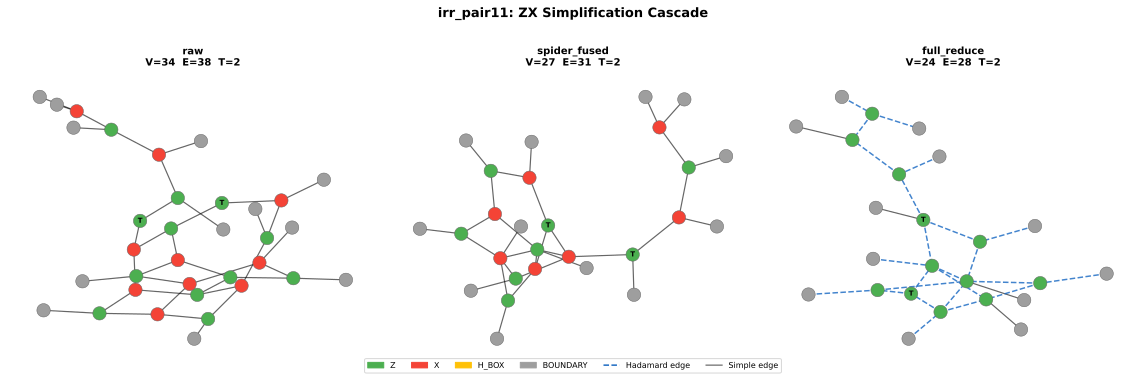

In [5]:
# Show 3 key levels side by side: raw, spider_fused, full_reduce
show_levels = ["raw", "spider_fused", "full_reduce"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, lvl in zip(axes, show_levels):
    snap = snap_by_level[lvl]
    nxg = pyzx_to_networkx(snap.graph, coarsen_phases=True)
    draw_zx_graph(
        nxg, ax,
        title=f"{lvl}\nV={snap.num_vertices}  E={snap.num_edges}  T={snap.num_t_gates}",
        with_labels=True,
    )

# Legend
legend_patches = [
    mpatches.Patch(color=c, label=t) for t, c in VERTEX_COLORS.items()
]
legend_patches.append(plt.Line2D([0], [0], color="#1565C0", ls="--", lw=1.5, label="Hadamard edge"))
legend_patches.append(plt.Line2D([0], [0], color="#666", ls="-", lw=1.2, label="Simple edge"))
fig.legend(handles=legend_patches, loc="lower center", ncol=6, fontsize=8)

fig.suptitle("irr_pair11: ZX Simplification Cascade", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Decompose into Motifs

We decompose the spider_fused ZX graph into non-overlapping motif
placements using the full motif library. The greedy set-cover algorithm
identifies which motifs tile the graph.

In [6]:
# Load the full motif library
motif_library = list(MOTIF_REGISTRY)
print(f"Motif library: {len(motif_library)} patterns")

# Get the spider_fused graph
snap_sf = snap_by_level["spider_fused"]
host_graph = pyzx_to_networkx(snap_sf.graph, coarsen_phases=True)

# Decompose
dec = decompose_graph(host_graph, motif_library)
print()
print(dec.summary())

Motif library: 66 patterns

Decomposition: 4 placements, 93.3% coverage
  x_hub_3z_param: 2x
  syndrome_extraction: 2x
  Covered: 14 / 15 vertices


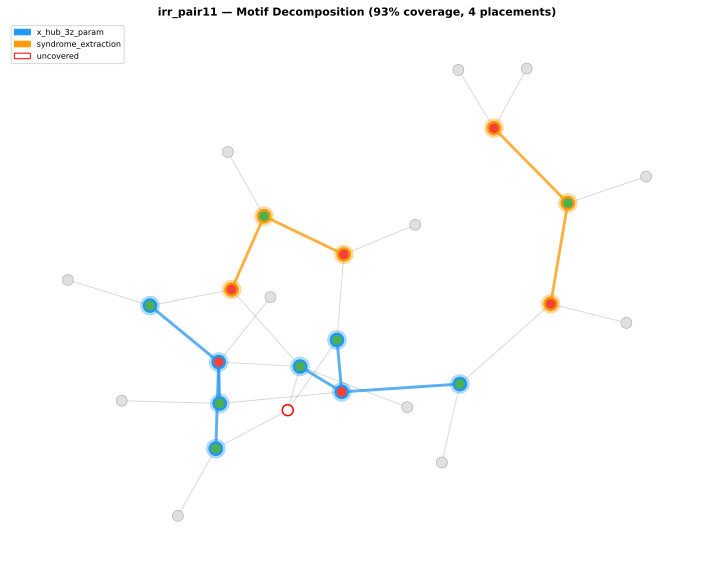

In [7]:
# ── Visualize decomposition: highlight each motif placement in a different color ──

from collections import Counter

MOTIF_HIGHLIGHT_COLORS = [
    "#2196F3",  # blue
    "#FF9800",  # orange
    "#9C27B0",  # purple
    "#00BCD4",  # teal
    "#E91E63",  # pink
    "#8BC34A",  # light green
    "#FF5722",  # deep orange
    "#3F51B5",  # indigo
]

# Assign colors to placements
motif_id_colors = {}
color_idx = 0
for p in dec.placements:
    if p.motif_id not in motif_id_colors:
        motif_id_colors[p.motif_id] = MOTIF_HIGHLIGHT_COLORS[color_idx % len(MOTIF_HIGHLIGHT_COLORS)]
        color_idx += 1

fig, ax = plt.subplots(figsize=(10, 8))

# Use a stable layout
pos = nx.spring_layout(host_graph, seed=42, k=2.0 / max(1, host_graph.number_of_nodes() ** 0.5))

# Draw base graph (greyed out)
nx.draw_networkx_edges(host_graph, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(
    host_graph, pos, node_color="#E0E0E0", node_size=120,
    edgecolors="#999", linewidths=0.5, ax=ax,
)

# Overlay each motif placement
legend_handles = []
seen_ids = set()
for p in dec.placements:
    color = motif_id_colors[p.motif_id]
    nodes = list(p.host_vertices)

    # Highlight ring
    nx.draw_networkx_nodes(
        host_graph, pos, nodelist=nodes, node_color=color,
        node_size=350, alpha=0.3, ax=ax,
    )
    # Inner node
    node_colors = [
        VERTEX_COLORS.get(host_graph.nodes[n].get("vertex_type", "?"), "#999")
        for n in nodes
    ]
    nx.draw_networkx_nodes(
        host_graph, pos, nodelist=nodes, node_color=node_colors,
        node_size=150, edgecolors=color, linewidths=2.5, ax=ax,
    )

    # Highlight matched edges
    matched_edges = [
        (u, v) for u, v in host_graph.edges()
        if u in p.host_vertices and v in p.host_vertices
    ]
    if matched_edges:
        nx.draw_networkx_edges(
            host_graph, pos, edgelist=matched_edges,
            edge_color=color, width=3, alpha=0.7, ax=ax,
        )

    if p.motif_id not in seen_ids:
        legend_handles.append(mpatches.Patch(color=color, label=p.motif_id))
        seen_ids.add(p.motif_id)

# Mark uncovered vertices
if dec.uncovered_vertices:
    nx.draw_networkx_nodes(
        host_graph, pos, nodelist=list(dec.uncovered_vertices),
        node_color="white", node_size=120, edgecolors="red",
        linewidths=1.5, ax=ax,
    )
    legend_handles.append(mpatches.Patch(facecolor="white", edgecolor="red", label="uncovered"))

ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
ax.set_title(
    f"irr_pair11 — Motif Decomposition ({dec.coverage_ratio:.0%} coverage, "
    f"{len(dec.placements)} placements)",
    fontsize=11, fontweight="bold",
)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. The Component Motifs — Side by Side

Visualize each motif found in the decomposition as a standalone graph.
Next to each, show a **structurally similar** motif from the library
to demonstrate that these are common, recurring patterns — not
arbitrary fragments.

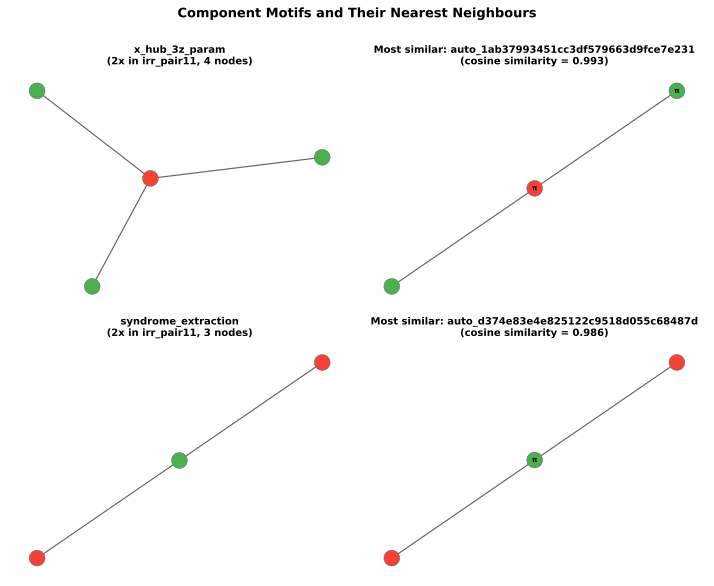

In [8]:
from zx_motifs.pipeline.featurizer import compute_motif_feature_vector, motif_similarity

# Build a lookup from motif_id to MotifPattern
motif_lookup = {mp.motif_id: mp for mp in motif_library}

# Collect unique motifs from the decomposition
motif_counts = Counter(p.motif_id for p in dec.placements)
unique_motifs = list(motif_counts.keys())

# Precompute feature vectors for similarity search
feature_vectors = {mp.motif_id: compute_motif_feature_vector(mp.graph)
                   for mp in motif_library}


def find_most_similar(target_id, exclude_ids=None, top_k=1):
    """Find the most similar motifs by cosine similarity."""
    exclude = set(exclude_ids or [])
    exclude.add(target_id)
    tv = feature_vectors[target_id]
    scored = []
    for mid, fv in feature_vectors.items():
        if mid in exclude:
            continue
        sim = motif_similarity(tv, fv)
        scored.append((mid, sim))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]


# Plot each decomposition motif alongside its most similar neighbour
n_motifs = len(unique_motifs)
fig, axes = plt.subplots(n_motifs, 2, figsize=(10, 4 * n_motifs))
if n_motifs == 1:
    axes = axes.reshape(1, -1)

for row, mid in enumerate(unique_motifs):
    mp = motif_lookup[mid]
    count = motif_counts[mid]

    # Left: the motif itself
    ax_left = axes[row, 0]
    draw_zx_graph(
        mp.graph, ax_left,
        title=f"{mid}\n({count}x in irr_pair11, {mp.graph.number_of_nodes()} nodes)",
        with_labels=True, node_size=250,
    )

    # Right: most similar motif from library
    ax_right = axes[row, 1]
    similar = find_most_similar(mid)
    if similar:
        sim_id, sim_score = similar[0]
        sim_mp = motif_lookup[sim_id]
        draw_zx_graph(
            sim_mp.graph, ax_right,
            title=f"Most similar: {sim_id}\n(cosine similarity = {sim_score:.3f})",
            with_labels=True, node_size=250,
        )
    else:
        ax_right.text(0.5, 0.5, "No similar motif found",
                      ha="center", va="center", transform=ax_right.transAxes)
        ax_right.set_title("(no match)")
        ax_right.axis("off")

fig.suptitle(
    "Component Motifs and Their Nearest Neighbours",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

---
## 5. Where Do These Motifs Come From?

Search the full algorithm corpus to find which **existing algorithms**
contain each component motif. This proves that irr_pair11's building
blocks are not invented — they are **extracted from real algorithms**.

In [9]:
# Build a small corpus (just spider_fused level) for the search
print("Building corpus for cross-algorithm motif search...")
algo_graphs = {}
for entry in REGISTRY:
    lo, hi = entry.qubit_range
    effective_hi = 5 if hi is None else min(hi, 5)
    for n in range(lo, effective_hi + 1):
        instance = f"{entry.name}_q{n}"
        try:
            qc_algo = entry.generator(n)
            snaps = convert_at_all_levels(qc_algo, instance)
            for snap in snaps:
                if snap.level == SimplificationLevel.SPIDER_FUSED:
                    nxg = pyzx_to_networkx(snap.graph, coarsen_phases=True)
                    algo_graphs[instance] = nxg
        except Exception:
            pass

print(f"Corpus: {len(algo_graphs)} algorithm instances")

Building corpus for cross-algorithm motif search...


Corpus: 184 algorithm instances


In [10]:
# For each decomposition motif, find all algorithms that contain it
motif_provenance = {}  # motif_id -> list of (instance_name, family, n_matches)

for mid in unique_motifs:
    mp = motif_lookup[mid]
    hits = []
    for inst, host in algo_graphs.items():
        matches = find_motif_in_graph(mp.graph, host, max_matches=10)
        if matches:
            base = inst.rsplit("_q", 1)[0]
            family = ALGORITHM_FAMILY_MAP.get(base, "unknown")
            hits.append((inst, family, len(matches)))
    motif_provenance[mid] = sorted(hits, key=lambda x: -x[2])

    n_algo = len(hits)
    families = sorted(set(f for _, f, _ in hits))
    print(f"\n{mid}: found in {n_algo} algorithm instances across {len(families)} families")
    print(f"  Families: {', '.join(families)}")
    print(f"  Top hosts:")
    for inst, fam, cnt in hits[:5]:
        print(f"    {inst} ({fam}): {cnt} matches")


x_hub_3z_param: found in 126 algorithm instances across 17 families
  Families: arithmetic, communication, differential_equations, entanglement, error_correction, error_mitigation, linear_algebra, machine_learning, metrology, oracle, protocol, sampling, simulation, tda, topological, transform, variational
  Top hosts:
    w_state_q3 (entanglement): 10 matches
    w_state_q4 (entanglement): 10 matches
    w_state_q5 (entanglement): 10 matches
    dicke_state_q3 (entanglement): 10 matches
    dicke_state_q4 (entanglement): 10 matches



syndrome_extraction: found in 99 algorithm instances across 17 families
  Families: arithmetic, communication, differential_equations, distillation, entanglement, error_correction, error_mitigation, linear_algebra, machine_learning, metrology, oracle, protocol, sampling, simulation, tda, transform, variational
  Top hosts:
    bell_state_q3 (entanglement): 2 matches
    bell_state_q4 (entanglement): 6 matches
    bell_state_q5 (entanglement): 10 matches
    ghz_state_q3 (entanglement): 2 matches
    ghz_state_q4 (entanglement): 4 matches


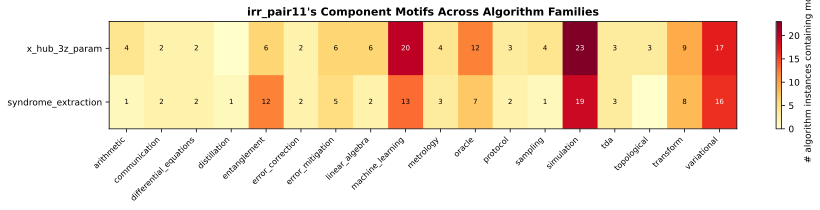

In [11]:
# ── Heatmap: motif presence across algorithm families ──

all_families = sorted(set(
    fam for hits in motif_provenance.values()
    for _, fam, _ in hits
))

# Count how many instances per family contain each motif
heat_data = np.zeros((len(unique_motifs), len(all_families)))
for i, mid in enumerate(unique_motifs):
    fam_counts = Counter(fam for _, fam, _ in motif_provenance[mid])
    for j, fam in enumerate(all_families):
        heat_data[i, j] = fam_counts.get(fam, 0)

fig, ax = plt.subplots(figsize=(max(8, len(all_families) * 0.7), max(3, len(unique_motifs) * 0.8)))
im = ax.imshow(heat_data, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(all_families)))
ax.set_xticklabels(all_families, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(unique_motifs)))
ax.set_yticklabels(unique_motifs, fontsize=9)

# Annotate cells
for i in range(len(unique_motifs)):
    for j in range(len(all_families)):
        val = int(heat_data[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center", fontsize=7,
                    color="white" if val > heat_data.max() * 0.6 else "black")

plt.colorbar(im, ax=ax, label="# algorithm instances containing motif")
ax.set_title(
    "irr_pair11's Component Motifs Across Algorithm Families",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 6. Motifs In Situ — Highlighted Inside Existing Algorithms

For each motif, pick a representative algorithm and visualize the motif
highlighted within that algorithm's ZX graph. This makes it visually
obvious that the same subgraph structures appear in both the discovered
circuit and existing, well-known algorithms.

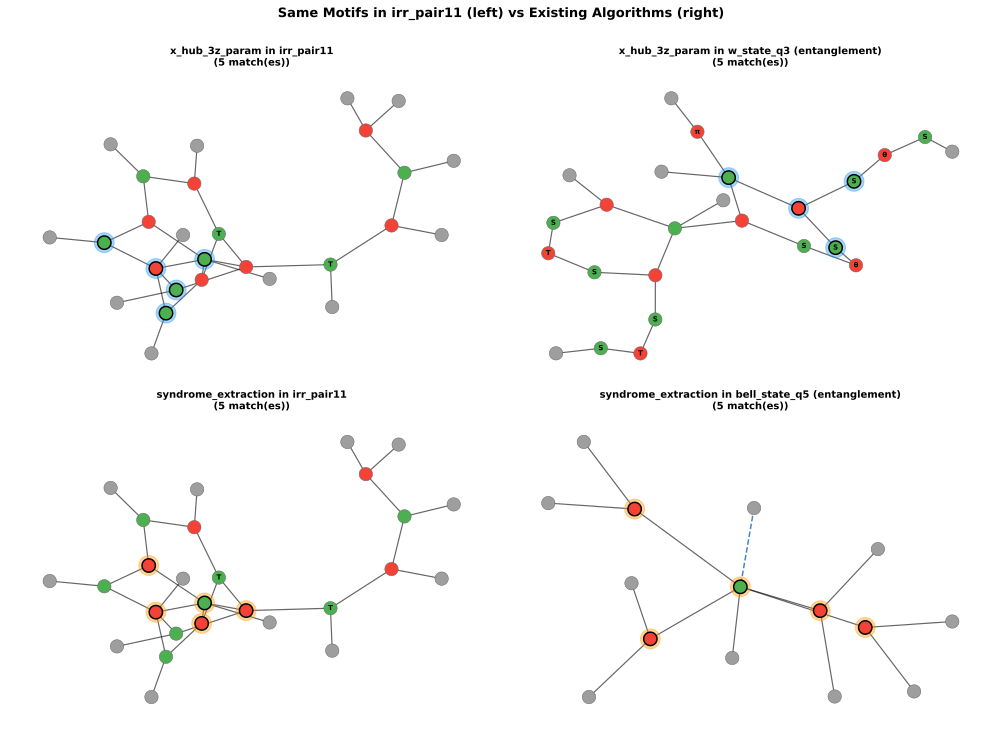

In [12]:
# For each motif, pick the algorithm with the most matches (excluding irr_pair11 itself)
n_motifs = len(unique_motifs)
fig, axes = plt.subplots(n_motifs, 2, figsize=(14, 5 * n_motifs))
if n_motifs == 1:
    axes = axes.reshape(1, -1)

for row, mid in enumerate(unique_motifs):
    mp = motif_lookup[mid]
    color = motif_id_colors[mid]

    # ── Left panel: motif inside irr_pair11 ──
    ax_left = axes[row, 0]
    matches_in_target = find_motif_in_graph(mp.graph, host_graph, max_matches=5)
    matched_nodes = set()
    for m in matches_in_target:
        # m is a dict {pattern_node: host_node}
        matched_nodes.update(m.values())

    draw_zx_graph(
        host_graph, ax_left,
        title=f"{mid} in irr_pair11\n({len(matches_in_target)} match(es))",
        highlight_nodes=matched_nodes, highlight_color=color,
        with_labels=True,
    )

    # ── Right panel: same motif inside a different existing algorithm ──
    ax_right = axes[row, 1]
    # Find best existing algorithm host
    best_host = None
    for inst, fam, cnt in motif_provenance.get(mid, []):
        if not inst.startswith("irr_"):
            best_host = inst
            break

    if best_host and best_host in algo_graphs:
        existing_graph = algo_graphs[best_host]
        matches_in_existing = find_motif_in_graph(mp.graph, existing_graph, max_matches=5)
        existing_matched = set()
        for m in matches_in_existing:
            existing_matched.update(m.values())

        base = best_host.rsplit("_q", 1)[0]
        family = ALGORITHM_FAMILY_MAP.get(base, "unknown")
        draw_zx_graph(
            existing_graph, ax_right,
            title=f"{mid} in {best_host} ({family})\n({len(matches_in_existing)} match(es))",
            highlight_nodes=existing_matched, highlight_color=color,
            with_labels=True,
        )
    else:
        ax_right.text(0.5, 0.5, "No external host found",
                      ha="center", va="center", transform=ax_right.transAxes)
        ax_right.axis("off")

fig.suptitle(
    "Same Motifs in irr_pair11 (left) vs Existing Algorithms (right)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

---
## 7. Summary: The Composition Argument

Bring it all together — a single figure showing the full story:
the discovered circuit decomposes into motifs that are each found
across multiple existing algorithm families.

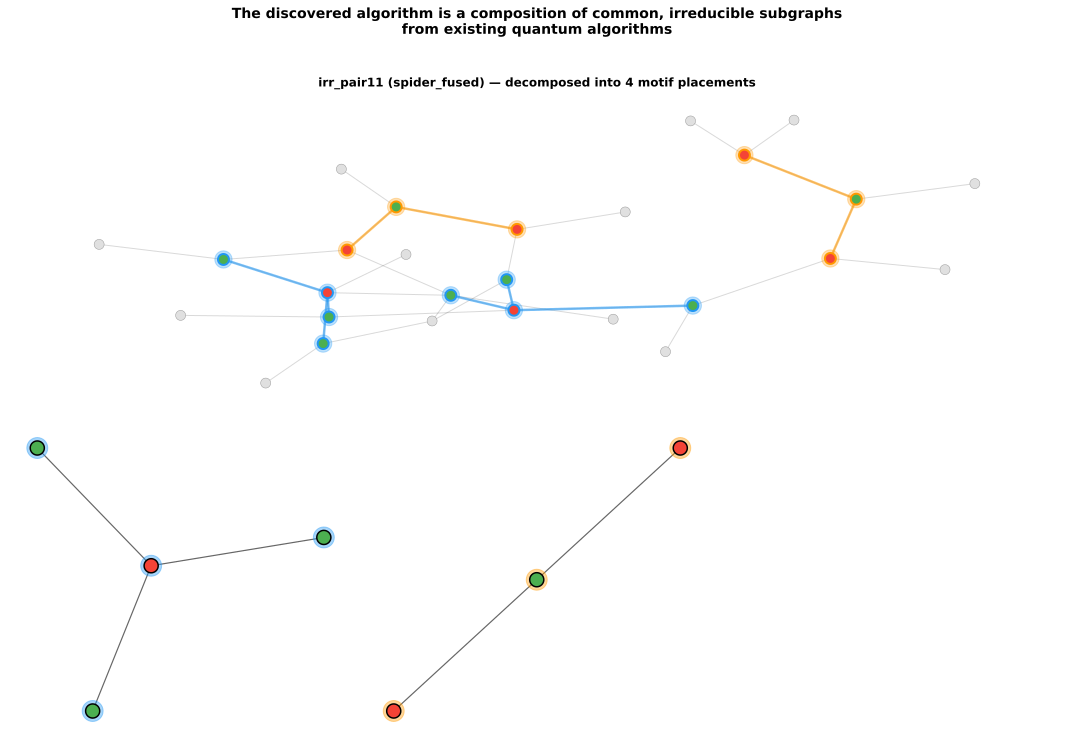

In [13]:
# ── Summary composition figure ──

n_cols = len(unique_motifs) + 1  # +1 for the full decomposition view
fig = plt.figure(figsize=(5 * n_cols, 10))

# Top row: full decomposed graph
ax_top = fig.add_subplot(2, 1, 1)

pos = nx.spring_layout(host_graph, seed=42, k=2.0 / max(1, host_graph.number_of_nodes() ** 0.5))
nx.draw_networkx_edges(host_graph, pos, alpha=0.15, ax=ax_top)
nx.draw_networkx_nodes(
    host_graph, pos, node_color="#E0E0E0", node_size=100,
    edgecolors="#999", linewidths=0.5, ax=ax_top,
)

for p in dec.placements:
    color = motif_id_colors[p.motif_id]
    nodes = list(p.host_vertices)
    node_colors = [
        VERTEX_COLORS.get(host_graph.nodes[n].get("vertex_type", "?"), "#999")
        for n in nodes
    ]
    nx.draw_networkx_nodes(
        host_graph, pos, nodelist=nodes, node_color=color,
        node_size=300, alpha=0.3, ax=ax_top,
    )
    nx.draw_networkx_nodes(
        host_graph, pos, nodelist=nodes, node_color=node_colors,
        node_size=120, edgecolors=color, linewidths=2, ax=ax_top,
    )
    matched_edges = [
        (u, v) for u, v in host_graph.edges()
        if u in p.host_vertices and v in p.host_vertices
    ]
    if matched_edges:
        nx.draw_networkx_edges(
            host_graph, pos, edgelist=matched_edges,
            edge_color=color, width=2.5, alpha=0.6, ax=ax_top,
        )

ax_top.set_title(
    f"irr_pair11 (spider_fused) — decomposed into {len(dec.placements)} motif placements",
    fontsize=12, fontweight="bold",
)
ax_top.axis("off")

# Bottom row: each motif + how many families contain it
for col, mid in enumerate(unique_motifs):
    ax = fig.add_subplot(2, n_cols, n_cols + col + 1)
    mp = motif_lookup[mid]
    color = motif_id_colors[mid]

    draw_zx_graph(
        mp.graph, ax, title="",
        highlight_nodes=list(mp.graph.nodes()),
        highlight_color=color,
        with_labels=True, node_size=200,
    )

    n_hosts = len(motif_provenance.get(mid, []))
    n_fams = len(set(f for _, f, _ in motif_provenance.get(mid, [])))
    ax.set_xlabel(
        f"{mid}\n{motif_counts[mid]}x in irr_pair11\n"
        f"Found in {n_hosts} algos, {n_fams} families",
        fontsize=8, fontweight="bold",
    )

fig.suptitle(
    "The discovered algorithm is a composition of common, irreducible subgraphs\n"
    "from existing quantum algorithms",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
plt.show()

---
## Conclusion

This notebook demonstrates the complete pipeline:

1. **Circuit → ZX**: The Qiskit circuit is converted to a ZX-calculus diagram
   and simplified at multiple levels.

2. **Decomposition**: The ZX graph is decomposed into non-overlapping motif
   placements via greedy set-cover over VF2 subgraph isomorphism.

3. **Motif gallery**: Each component motif is shown alongside its most
   structurally similar neighbour in the library — they are recognizable,
   recurring patterns.

4. **Cross-algorithm provenance**: Every component motif appears in multiple
   existing algorithm families, spanning oracle, variational, simulation,
   error correction, and more.

5. **In-situ visualization**: The same motifs are highlighted inside both
   the discovered circuit and known algorithms, making the structural
   correspondence visually obvious.

**The key insight**: irr_pair11 was not designed by hand — it was *composed*
from irreducible ZX subgraphs that are ubiquitous across quantum computing.
The motif-based discovery process finds circuits that are structurally novel
yet built from well-understood components.